# Steam Game Pricing Analysis
## The Importance of Price!
A Pricing Optimization Analysis by Anubad Mahapatra<br>
Available on GitHub

## Preliminary Steps
### Imports
For this project we will be using:
* `pandas`
* `numpy`
* `os`
* `datasets`
* `dotenv`
* `scikit-learn`
* `matplotlib`'s `pyplot`
* `seaborn`

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import re
import os
from dotenv import load_dotenv
from datasets import load_dataset
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

### Load the Dataset
The dataset is found on HuggingFace, and is composed of

In [2]:
# Keeps the output clean from deprecation warnings
warnings.filterwarnings('ignore') 

print("=== Steam Games Pricing Analysis ===")

# Define where we want to save our local copy
data_dir = "data"
local_file_path = os.path.join(data_dir, "steam_games_raw.csv")

# Create the data directory if it doesn't exist yet
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

try:
    # 1. Check if we already downloaded the data previously
    if os.path.exists(local_file_path):
        print(f"[1/2] Found local dataset at '{local_file_path}'. Loading from disk...")
        df = pd.read_csv(local_file_path)
        print("[2/2] Local data loaded instantly!\n")
        
    else:
        # 2. If no local copy exists, download from Hugging Face
        print("[1/4] Local copy not found. Loading environment variables...")
        load_dotenv()
        hf_token = os.getenv("HF_TOKEN")

        print("[2/4] Initializing connection to Hugging Face...")
        ds = load_dataset("FronkonGames/steam-games-dataset", split="train", token=hf_token)
        
        print("[3/4] Dataset downloaded! Converting to pandas DataFrame...")
        df = pd.DataFrame(ds)
        
        print(f"[4/4] Saving a local copy to '{local_file_path}' for future runs...")
        # Save to CSV so we can load it locally next time
        df.to_csv(local_file_path, index=False)
        print("Save complete!\n")
except Exception as e:
    print("\n[ERROR] Failed to load the dataset!")
    print(f"Error Details: {e}")
    print("\nTroubleshooting Tips:")
    print("1. If using Hugging Face: Check if your .env file is formatted exactly as: HF_TOKEN=your_token")
    print("2. Check your internet connection.")

=== Steam Games Pricing Analysis ===
[1/2] Found local dataset at 'data/steam_games_raw.csv'. Loading from disk...
[2/2] Local data loaded instantly!



### The Dataset

In [3]:
# 1. Basic Structure
print("\n--- Dataset Info ---")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")

# 2. Check for missing values (Nulls/NaNs)
print("\n--- Missing Values ---")
missing_data = df.isnull().sum()
missing_data_gt_0 = missing_data[missing_data > 0]
if len(missing_data_gt_0) > 0:
    print(missing_data_gt_0) # Only show columns with missing data
else:
    print("Missing Values: 0")

# 3. Check for Duplicate entries
# AppID is the unique identifier for a game on Steam
duplicate_count = df.duplicated(subset=['appID']).sum()
print(f"\n--- Duplicates ---")
print(f"Duplicate games found: {duplicate_count}")

# Look at the first 3 rows to confirm it loaded correctly
df.head(3)


--- Dataset Info ---
Total Rows: 124146
Total Columns: 41

--- Missing Values ---
name                         1
detailed_description      8428
short_description         8315
reviews                 112022
header_image                81
website                  74081
support_url              69463
support_email            22429
metacritic_url          119889
score_rank              124106
notes                   101279
dtype: int64

--- Duplicates ---
Duplicate games found: 0


,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,...,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,NaN,NaN,...,0,0,[],[],[],[],[],['https://shared.akamai.steamstatic.com/store_...,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,0,"Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",...,8,0,['minori'],['MangaGamer'],"['Single-player', 'Steam Trading Cards', 'Stea...",['Adventure'],[],['https://shared.akamai.steamstatic.com/store_...,[],"[{""title"": ""Buy Supipara - Chapter 1 Spring Ha..."
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,...,0,0,['Somer Games'],['8floor'],"['Single-player', 'Family Sharing']",['Casual'],[],['https://shared.akamai.steamstatic.com/store_...,[],"[{""title"": ""Buy Mystery Solitaire The Black Ra..."


### Preprocessing
1. Remove duplicate entries.
2. Remove games with missing names
3. Replace the range of values for `estimated_owners` to the midpoint value.

In [4]:
print("Starting Preprocessing...")

# 1. Drop Duplicates (if any exist)
if duplicate_count > 0:
    df = df.drop_duplicates(subset=['appID'], keep='first')
    print("Duplicates removed.")

# 2. Function to convert 'estimated_owners' range strings to a numeric midpoint
def parse_owners(owner_str):
    if pd.isna(owner_str) or owner_str == '0 - 0':
        return 0
    # Extract numbers from strings like '20000 - 50000'
    numbers = [int(s) for s in re.findall(r'\d+', str(owner_str))]
    if len(numbers) == 2:
        return sum(numbers) / 2
    return numbers[0] if numbers else 0

# Apply the conversion to create our Demand metric
df['owners_midpoint'] = df['estimated_owners'].apply(parse_owners)

# 3. Date Conversion
# Convert string dates to actual datetime objects so we can filter by year later
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# 4. Create our Revenue Proxy and filter for "Premium" games
df['est_revenue'] = df['price'] * df['owners_midpoint']

# We filter out Free games (price == 0) because they use a microtransaction 
# business model, which doesn't fit a standard premium price elasticity analysis.
df_premium = df[df['price'] > 0].copy()

print(f"\nPreprocessing Complete!")
print(f"Total Premium Games ready for analysis: {len(df_premium)}")
df_premium[['name', 'price', 'owners_midpoint', 'est_revenue', 'release_year']].head()

Starting Preprocessing...

Preprocessing Complete!
Total Premium Games ready for analysis: 97734


,name,price,owners_midpoint,est_revenue,release_year
1,Supipara - Chapter 1 Spring Has Come!,5.24,10000.0,52400.0,2016
2,Mystery Solitaire The Black Raven,4.99,10000.0,49900.0,2019
3,버튜버 파라노이아 - Vtuber Paranoia,8.99,10000.0,89900.0,2024
4,Maze Quest VR,4.99,10000.0,49900.0,2025
5,Agony VR,13.99,10000.0,139900.0,2023


# Exploratory Data Analysis
## Revenue vs. Genre
Showing how much a genre makes provides key insight into how much a game should be priced for.

--- Encoding Genre Data ---
Total Unique Genres Found: 104
Top 10 Genres: ['Action', 'Indie', 'Indie'], 'Casual', ['Adventure', ['Casual', 'Adventure', 'Strategy'], 'Simulation'], 'Early Access']

Calculating genre metrics...


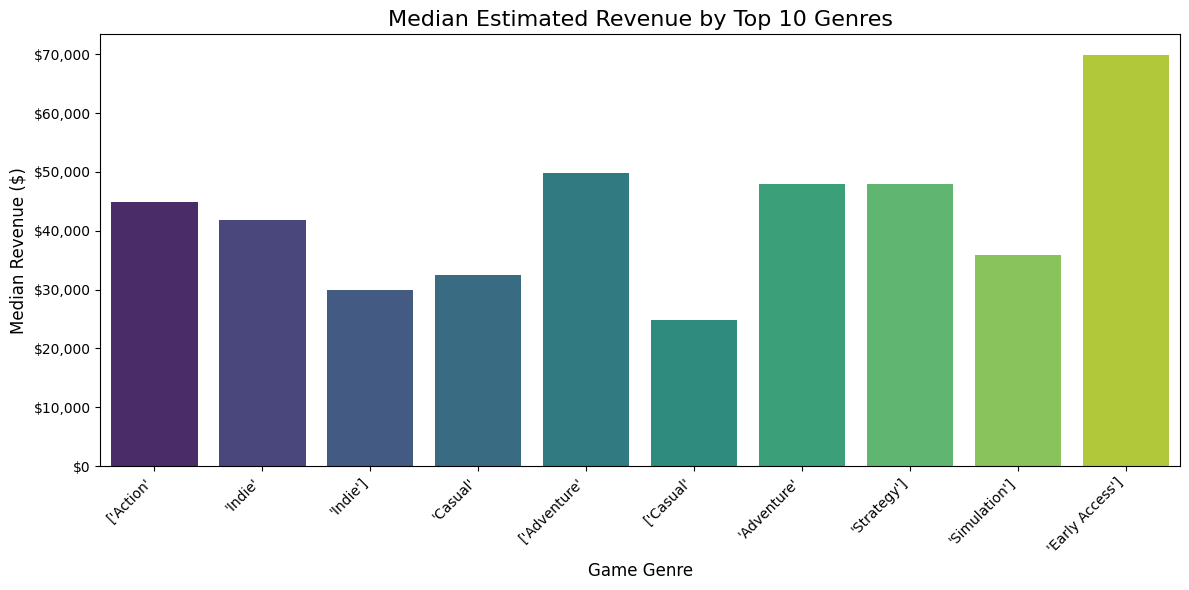

In [5]:
print("--- Encoding Genre Data ---")

# We use df_premium as our base for analysis
df_analysis = df_premium.copy()

# 1. Clean the genres column
def clean_genres(g):
    if pd.isna(g):
        return []
    if isinstance(g, str):
        return [genre.strip() for genre in g.split(',')]
    return g

df_analysis['genres_list'] = df_analysis['genres'].apply(clean_genres)

# 2. Initialize and fit MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df_analysis['genres_list'])

# 3. Create genre DataFrame and join it back
genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=df_analysis.index)
df_analysis = df_analysis.join(genre_df)

# 4. Calculate the total counts and select TOP 10
genre_counts = genre_df.sum().sort_values(ascending=False)
top_genres = genre_counts.index.tolist()[:10]  # FIX: Limit to Top 10

print(f"Total Unique Genres Found: {len(mlb.classes_)}")
print(f"Top 10 Genres: {', '.join(top_genres)}")

print("\nCalculating genre metrics...")

genre_revenue_data = []
for genre in top_genres:
    genre_subset = df_analysis[df_analysis[genre] == 1]
    
    genre_revenue_data.append({
        'Genre': genre,
        'Median Revenue ($)': genre_subset['est_revenue'].median(),
        'Median Price ($)': genre_subset['price'].median(),
        'Total Games': len(genre_subset)
    })

df_genre_metrics = pd.DataFrame(genre_revenue_data)

# 5. Visualization
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_genre_metrics, 
    x='Genre', 
    y='Median Revenue ($)', 
    hue='Genre',
    palette='viridis',
    legend=False
)

plt.title('Median Estimated Revenue by Top 10 Genres', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

plt.tight_layout()
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/median_revenue_by_genre.png')
plt.show()

### The "Early Access" Problem
The Genre-Revenue graph currently shows that "Early Access" is a high-earner! However, this feature isn't actually a genre but is actually a different feature entirely. Therefore, it must be removed as a genre. However, there are 2 questions that must be answered before this can be done:
1. **Can a game be of multiple genres?**<br>
**YES**, a game can be of multiple genres, since we actually had to use the `MultiLabelBinarizer` from `sklearn`.<br><br>
2. **Are there any games that are only of the genre "Early Access"?**<br>
To answer this, let's look at the data directly to see how many games fall into this trap. Depending on the number, we can safely remove "Early Access" from the list of valid genres, treat it as a separate binary feature (a release model), and re-render our true market leaders.

In [6]:
print("--- Investigating Early Access & Genres ---")

# 1. Answer Question 1: How many games have multiple genres?
# We calculate this using the genre_df we created in the previous step
df_analysis['genre_count'] = genre_df.sum(axis=1)
multi_genre = len(df_analysis[df_analysis['genre_count'] > 1])
print(f"Games with multiple genres: {multi_genre:,}")

# 2. Answer Question 2: Are there games with ONLY 'Early Access'?
# We check if 'Early Access' exists in the columns to prevent the KeyError
if 'Early Access' in df_analysis.columns:
    only_ea_games = df_analysis[(df_analysis['Early Access'] == 1) & (df_analysis['genre_count'] == 1)]
    print(f"Games with ONLY 'Early Access' as a genre: {len(only_ea_games):,}")
else:
    print("Games with ONLY 'Early Access' as a genre: 0")

# 3. Answer Question 3: How many games had NO genres at all originally?
no_genre_games = len(df_analysis[df_analysis['genre_count'] == 0])
print(f"Games with NO genres at all originally: {no_genre_games:,}")

--- Investigating Early Access & Genres ---
Games with multiple genres: 82,558
Games with ONLY 'Early Access' as a genre: 0
Games with NO genres at all originally: 0


### Titles with No Genre
There appears to be 136 titles that would be left without a genre if *Early Access* is removed as a genre. Let's categorize these titles as *No Genre*. They still earn money, so it would be unfair to remove them from consideration just because the developer didn't label them (or the scraper could not parse them)!

In [7]:
print("\n--- Cleaning the Data ---")

# 4. Implement your fix: Create a dedicated 'is_early_access' binary column
df_analysis['is_early_access'] = df_analysis['Early Access']

# 5. Remove 'Early Access' from our list of valid genres
valid_genres = list(mlb.classes_)
if 'Early Access' in valid_genres:
    valid_genres.remove('Early Access')

# 6. Keep orphaned games by assigning them to "Uncategorized"
df_analysis['valid_genre_count'] = genre_df[valid_genres].sum(axis=1)
zero_genre_count = (df_analysis['valid_genre_count'] == 0).sum()

print(f"Found {zero_genre_count:,} games with no valid gameplay genres. Labeling as 'No Genre'.")

# Create the new genre column
df_analysis['No Genre'] = (df_analysis['valid_genre_count'] == 0).astype(int)
valid_genres.append('No Genre') # Add it to our list of genres to analyze

# We keep 100% of the games now
df_clean = df_analysis.copy()
print(f"Games remaining for analysis: {len(df_clean):,}")

print("\n--- Recalculating Top Genres & Metrics ---")

# 7. Recalculate the Top 10 TRUE Genres
genre_counts_clean = df_clean[valid_genres].sum().sort_values(ascending=False).head(10)
top_genres_clean = genre_counts_clean.index.tolist()

print(f"New Top 10 Genres: {', '.join(top_genres_clean)}")

# 8. Recalculate the metrics for the chart
genre_revenue_data = []
for genre in top_genres_clean:
    genre_subset = df_clean[df_clean[genre] == 1]
    
    genre_revenue_data.append({
        'Genre': genre,
        'Median Revenue ($)': genre_subset['est_revenue'].median(),
        'Median Price ($)': genre_subset['price'].median(),
        'Total Games': len(genre_subset)
    })

df_genre_metrics = pd.DataFrame(genre_revenue_data)

# 9. Render the Corrected Chart
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_genre_metrics, 
    x='Genre', 
    y='Median Revenue ($)', 
    hue='Genre',
    palette='viridis',
    legend=False
)

plt.title('Median Estimated Revenue by Top 10 Genres', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
plt.tight_layout()

# Save the cleaned plot as a PNG file in the graphs subdirectory
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/median_revenue_by_genre_cleaned.png')
print("\nCleaned plot saved to 'graphs/median_revenue_by_genre_cleaned.png'")

plt.show()


--- Cleaning the Data ---


KeyError: 'Early Access'

## Concurrent Players
Revenue isn't everything. Oftentimes, a title that generates lots of revenue does so by utilizing anti-consumer practices that turn players away from future releases from the same publisher or developer. High values of **concurrent players** also contribute to determining a game's "value" and should also be utilized to determine pricing. Of course, since players must pay the price first in order to play the game, this is a "retroactive" feature. That is, the concurrent player number may be a result of the pricing, not the other way around.<br><br>
Regardless, plotting the concurrent players vs the game genre can provide some insight into how many people play games of a certain genre long-term. Let's do that now.

In [ ]:
print("--- Calculating Peak CCU by Genre ---")

# Let's dynamically find the CCU column (usually 'peak_ccu' in this dataset)
ccu_col = 'peak_ccu' if 'peak_ccu' in df_clean.columns else 'Peak CCU'

ccu_data = []
for genre in top_genres_clean:
    genre_subset = df_clean[df_clean[genre] == 1]
    
    # We use median because a few games with millions of CCUs will break the average
    median_ccu = genre_subset[ccu_col].median()
    
    ccu_data.append({
        'Genre': genre,
        'Median Peak CCU': median_ccu
    })

df_ccu_metrics = pd.DataFrame(ccu_data)

# Sort by CCU for a better visual flow
df_ccu_metrics = df_ccu_metrics.sort_values(by='Median Peak CCU', ascending=False)

# Render the Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_ccu_metrics, 
    x='Genre', 
    y='Median Peak CCU', 
    hue='Genre',
    palette='magma', # Using a different color palette to distinguish from Revenue
    legend=False
)

plt.title('Median Peak Concurrent Users (CCU) by Top 10 Genres', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Peak CCU (Players)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Format Y-axis to add commas (e.g., 1,500)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()

os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/median_ccu_by_genre.png')
print("Saved plot to 'graphs/median_ccu_by_genre.png'")

plt.show()

### The "Dead Game" Phenomenon (Fixing the Blank Graph)
Looking at the graph above, it appears entirely blank. Did the code fail? Actually, it didn't! The code executed perfectly, but it revealed a harsh reality of the Steam marketplace: **The overwhelming majority of games on Steam are "dead."**

Because Steam has very low barriers to entry, the store is flooded with abandoned student projects, asset flips (titles that leave default placeholder engine assets in place of created assets), and forgotten indie titles that have a Peak Concurrent User (CCU) count of exactly **0**. Because we used the **Median** to calculate our metric, these tens of thousands of dead games dragged the mathematical middle point for every single genre down to literal zero.

To get an accurate picture of the market, we need to filter our dataset to only include **Active Games**—titles that successfully attracted at least 1 concurrent player. As such, let's remove these titles from consideration entirely and redraw the market matrix.

In [ ]:
print("--- Recalculating Peak CCU (Active Games Only) ---")

# 1. Filter out the "dead" games that drag the median to 0
# We use ccu_col which was defined in the previous cell
df_active_games = df_clean[df_clean[ccu_col] > 0].copy()

dead_games_dropped = len(df_clean) - len(df_active_games)
print(f"Dropped {dead_games_dropped:,} 'dead' games with 0 peak concurrent players.")
print(f"Games with >0 CCU remaining for analysis: {len(df_active_games):,}")
print(f"Percentage of data dropped: {dead_games_dropped / len(df_clean) * 100:.2f}%")

# 2. Recalculate the metrics
ccu_data_active = []
for genre in top_genres_clean:
    genre_subset = df_active_games[df_active_games[genre] == 1]
    
    # Calculate the median on games that actually have a player base
    median_ccu = genre_subset[ccu_col].median()
    
    ccu_data_active.append({
        'Genre': genre,
        'Median Peak CCU': median_ccu
    })

df_ccu_metrics_active = pd.DataFrame(ccu_data_active)
df_ccu_metrics_active = df_ccu_metrics_active.sort_values(by='Median Peak CCU', ascending=False)

# 3. Render the Corrected Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_ccu_metrics_active, 
    x='Genre', 
    y='Median Peak CCU', 
    hue='Genre',
    palette='magma', 
    legend=False
)

plt.title('Median Peak Concurrent Users (CCU) by Top 10 Genres (Active Games Only)', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Peak CCU (Active Players)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Format Y-axis to add commas cleanly
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()

# Save the corrected plot with a new filename
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/median_ccu_by_genre_active.png')
print("\nSaved corrected plot to 'graphs/median_ccu_by_genre_active.png'")

plt.show()

To little surprise, the *Massively Multiplayer* genre also has a large median concurrent player base. As the previous cell showed, a whopping 80,243 titles had *no concurrent players*! This composed 82.10% of all titles! Because of this large change in the dataset, let's recreate Revenue vs Genre graph so that we can see if anything's changed after dropping all the abandonware.

In [ ]:
print("--- Recreating Cleaned Revenue Graph: ACTIVE GAMES ONLY ---")
os.makedirs('graphs', exist_ok=True)

# 1. State Management: Save the original and update the main 'df'
# We use df_clean as the original because it contains the 100% complete dataset 
# with the 'No Genre' categorization successfully applied.
originalDF = df_clean.copy() 
df = df_active_games.copy()

print(f"Original dataset (100% of games) saved to 'originalDF'. Size: {len(originalDF):,}")
print(f"Active games dataset set to main 'df'. Size: {len(df):,}")

# 2. Recalculate the Median Revenue metrics using the new main 'df'
revenue_data_active = []

# We use 'top_genres_clean' to keep the exact same X-axis categories for a 1:1 comparison
for genre in top_genres_clean:
    genre_subset = df[df[genre] == 1]
    revenue_data_active.append({
        'Genre': genre,
        'Median Revenue ($)': genre_subset['est_revenue'].median()
    })

df_rev_active = pd.DataFrame(revenue_data_active)

# 3. Render the Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_rev_active, 
    x='Genre', 
    y='Median Revenue ($)', 
    hue='Genre', 
    palette='viridis', 
    legend=False
)

plt.title('Median Estimated Revenue by Top 10 Genres (Active Games Only)', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Format Y-axis to add dollars and commas cleanly
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
plt.tight_layout()

# 4. Save with a distinct filename
plt.savefig('graphs/median_revenue_by_genre_cleaned_active.png')
print("\nSaved plot to 'graphs/median_revenue_by_genre_cleaned_active.png'")

plt.show()

## Total Playtime
Financial success (Revenue) and viral engagement (Peak CCU) are crucial, but they don't tell the whole story. To truly understand the value proposition of a genre, we must look at **Player Retention**, measured by Median Playtime. 

Does a high price tag guarantee a long, engaging experience? Do certain genres command massive loyalty and hundreds of hours of gameplay? By analyzing the median playtime of our active market (games with >0 concurrent players), we can see which genres keep players coming back for more. 

*Note: Steam typically tracks playtime in minutes, so we will convert this data into hours for a clearer business visualization.*

In [ ]:
print("--- Calculating Playtime by Genre ---")

# 1. Dynamically find the Playtime column 
if 'median_playtime_forever' in df.columns:
    playtime_col = 'median_playtime_forever'
elif 'average_playtime_forever' in df.columns:
    playtime_col = 'average_playtime_forever'
else:
    playtime_col = [col for col in df.columns if 'playtime' in col.lower()][0]

# 2. Calculate the metrics
playtime_data = []

for genre in top_genres_clean:
    genre_subset = df[df[genre] == 1]
    
    # Convert minutes to hours
    median_playtime_minutes = genre_subset[playtime_col].median()
    median_playtime_hours = median_playtime_minutes / 60.0
    
    playtime_data.append({
        'Genre': genre,
        'Median Playtime (Hours)': median_playtime_hours
    })

df_playtime_metrics = pd.DataFrame(playtime_data)
df_playtime_metrics = df_playtime_metrics.sort_values(by='Median Playtime (Hours)', ascending=False)

# 3. Render the Chart
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_playtime_metrics, 
    x='Genre', 
    y='Median Playtime (Hours)', 
    hue='Genre',
    palette='crest', 
    legend=False
)

plt.title('Median Playtime by Top 10 Genres', fontsize=16)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Median Playtime (Hours)', fontsize=12)
plt.xticks(rotation=45, ha='right')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.1f} hrs".format(x)))
plt.tight_layout()

# 4. Save and Show
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/median_playtime_by_genre.png')
print(f"\nSaved plot to 'graphs/median_playtime_by_genre.png'")

plt.show()